# Section 2 — Missing Value Identification and Basic Imputation 
## Overview
Missing values in this dataset are encoded as `-200`, not NaN. This section replaces the sentinel, quantifies missingness per column, applies a 40% threshold to decide keep/remove/impute, removes rows without a valid datetime, drops `NMHC(GT)` (90.3% missing), and imputes remaining numerical gaps with the **median** (robust to skew and pollution spikes).

## Key Results

| Metric | Before | After |
|--------|--------|-------|
| Rows | 9,471 | 9,357 (−114 rows without datetime) |
| Columns | 16 | 15 (`NMHC(GT)` removed) |
| Total missing values | 18,525 | 0 |
| Missingness threshold | — | 40% |
| Imputation strategy | — | Median for 12 numerical columns |

## Learning Objectives
- Replace `-200` sentinel values with NaN
- Compute missing-value counts and percentages per column
- Apply at least two basic strategies: removal + mean/median imputation

## Your Decisions Log

| Step | Decision | Evidence (plot / table / stat) |
|------|----------|--------------------------------|
| Replace sentinel | Map `-200` → NaN across all columns | Top missing: NMHC(GT) 8,557 (90.3%) |
| Missingness threshold | 40% — columns above are removed | Dashed line on `missingness_by_column.png` |
| Remove column | Drop `NMHC(GT)` (90.3% missing) | Action table — `remove` |
| Remove rows | Drop 114 rows with invalid `Datetime` | 9,471 → 9,357 rows |
| Impute | Median for 12 numerical columns | `CO(GT)`, `NO2(GT)`, `NOx(GT)`, sensors, `T`, `RH`, `AH` |
| Visual evidence | Bar chart of missing % per column | `reports/figures/missingness_by_column.png` |

## Required Formulas
- Missing % = (missing count / total rows) × 100
- Mean imputation: x̂ = x̄
- Median imputation: x̂ = median(X)

## Tasks
- a) Replace -200 with NaN
- b) Calculate missing count and percentage per column
- c) Decide keep / remove / impute for each column
- d) Apply removal + mean or median imputation
- e) Justify each decision with a clear criterion

In [1]:
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from IPython.display import display

from src.config import RAW_DATA_PATH, MISSING_SENTINEL, MISSINGNESS_THRESHOLD, FIGURES_DIR
from src.load_data import load_raw_air_quality, build_datetime
from src.plot_style import apply_plot_style, style_table, PALETTE
from src.missing_values import (
    replace_sentinel_with_nan,
    missing_summary,
    decide_column_action,
    impute_basic,
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
apply_plot_style()

# Start from the raw dataset and rebuild the datetime column so this notebook can run on its own.
df = load_raw_air_quality(RAW_DATA_PATH)
df = build_datetime(df)
print("=" * 72)
print("DATETIME COLUMN MODIFICATION")
print("=" * 72)
display(style_table(df[['Date', 'Time', 'Datetime']].head()))

DATETIME COLUMN MODIFICATION


Date,Time,Datetime
10/03/2004,18.00.00,2004-03-10 18:00:00
10/03/2004,19.00.00,2004-03-10 19:00:00
10/03/2004,20.00.00,2004-03-10 20:00:00
10/03/2004,21.00.00,2004-03-10 21:00:00
10/03/2004,22.00.00,2004-03-10 22:00:00


In [2]:
# Replace the dataset's sentinel value with proper missing values.
df = replace_sentinel_with_nan(df, sentinel=MISSING_SENTINEL)
print('Sentinel values replaced with NaN.')
print(df.isna().sum().sort_values(ascending=False).head(10).to_string())

Sentinel values replaced with NaN.
NMHC(GT)         8557
CO(GT)           1797
NO2(GT)          1756
NOx(GT)          1753
C6H6(GT)          480
PT08.S2(NMHC)     480
PT08.S3(NOx)      480
PT08.S1(CO)       480
T                 480
RH                480


In [3]:
# Summarize missingness and sort the columns from most affected to least affected.
missing_df = missing_summary(df).sort_values('missing_pct', ascending=False).reset_index(drop=True)
display(style_table(missing_df))

column,missing_count,missing_pct
NMHC(GT),8557,90.349488
CO(GT),1797,18.973709
NO2(GT),1756,18.540809
NOx(GT),1753,18.509133
C6H6(GT),480,5.068103
PT08.S2(NMHC),480,5.068103
PT08.S3(NOx),480,5.068103
PT08.S1(CO),480,5.068103
T,480,5.068103
RH,480,5.068103


In [4]:
# Translate missingness into a simple keep/remove/impute decision per column.
missing_df['action'] = missing_df['missing_pct'].apply(
    lambda pct: decide_column_action(pct, MISSINGNESS_THRESHOLD)
)
display(style_table(missing_df[['column', 'missing_count', 'missing_pct', 'action']]))

column,missing_count,missing_pct,action
NMHC(GT),8557,90.349488,remove
CO(GT),1797,18.973709,impute
NO2(GT),1756,18.540809,impute
NOx(GT),1753,18.509133,impute
C6H6(GT),480,5.068103,impute
PT08.S2(NMHC),480,5.068103,impute
PT08.S3(NOx),480,5.068103,impute
PT08.S1(CO),480,5.068103,impute
T,480,5.068103,impute
RH,480,5.068103,impute


In [5]:
# Drop the columns with excessive missingness, remove rows without a usable datetime, and impute the rest with the median.
columns_to_remove = missing_df.loc[missing_df['action'] == 'remove', 'column'].tolist()
columns_to_impute = missing_df.loc[missing_df['action'] == 'impute', 'column'].tolist()
columns_to_impute = [column for column in columns_to_impute if column not in {'Date', 'Time', 'Datetime'}]

df_clean = df.dropna(subset=['Datetime']).drop(columns=columns_to_remove)
df_clean = impute_basic(df_clean, columns=columns_to_impute, strategy='median')

print('Removed columns:', columns_to_remove)
print('Imputed columns:', columns_to_impute)
display(style_table(df_clean.head()))

Removed columns: ['NMHC(GT)']
Imputed columns: ['CO(GT)', 'NO2(GT)', 'NOx(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S1(CO)', 'T', 'RH', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'AH']


Date,Time,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime
10/03/2004,18.00.00,2.600000,1360.000000,11.900000,1046.000000,166.000000,1056.000000,113.000000,1692.000000,1268.000000,13.600000,48.900000,0.757800,2004-03-10 18:00:00
10/03/2004,19.00.00,2.000000,1292.000000,9.400000,955.000000,103.000000,1174.000000,92.000000,1559.000000,972.000000,13.300000,47.700000,0.725500,2004-03-10 19:00:00
10/03/2004,20.00.00,2.200000,1402.000000,9.000000,939.000000,131.000000,1140.000000,114.000000,1555.000000,1074.000000,11.900000,54.000000,0.750200,2004-03-10 20:00:00
10/03/2004,21.00.00,2.200000,1376.000000,9.200000,948.000000,172.000000,1092.000000,122.000000,1584.000000,1203.000000,11.000000,60.000000,0.786700,2004-03-10 21:00:00
10/03/2004,22.00.00,1.600000,1272.000000,6.500000,836.000000,131.000000,1205.000000,116.000000,1490.000000,1110.000000,11.200000,59.600000,0.788800,2004-03-10 22:00:00


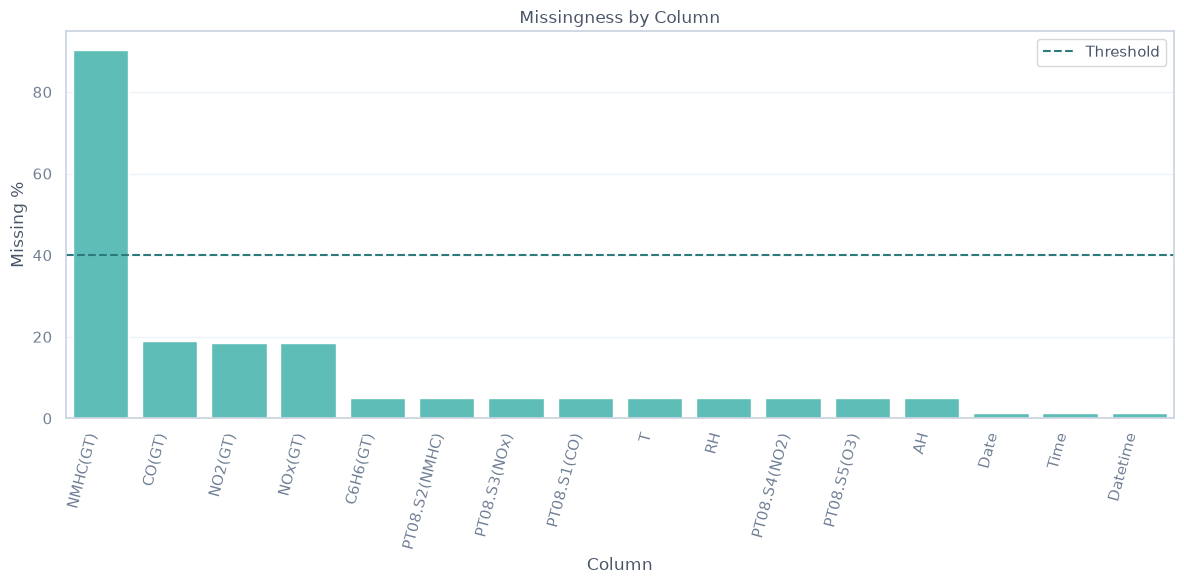

In [6]:
# Visualize the missing-value profile so the decision threshold is easy to justify.
plt.figure(figsize=(12, 6))
sns.barplot(data=missing_df, x='column', y='missing_pct', color=PALETTE['aqua_primary'])
plt.axhline(MISSINGNESS_THRESHOLD * 100, color=PALETTE['aqua_dark'], linestyle='--', label='Threshold')
plt.xticks(rotation=75, ha='right')
plt.ylabel('Missing %')
plt.xlabel('Column')
plt.title('Missingness by Column')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'missingness_by_column.png', dpi=150, bbox_inches='tight')
plt.show()

## Guiding Questions

1. **What threshold did you use to decide whether a column had excessive missingness?**

   I used a 40% missingness threshold. Columns above that cutoff were treated as excessive and removed; columns below it were kept and either imputed or left unchanged depending on their role in the analysis.

2. **Why is the median sometimes preferable to the mean when imputing numerical variables?**

   The median is more robust to skewed distributions and extreme values. For air-quality data, where occasional spikes and outliers are common, the median usually gives a more representative central value than the mean.